# Forecasting Baselines
This notebook evaluates our simple seasonal baseline models before generating more complex ML models. We can visualize the performance here.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Add src to module path for importing custom code
sys.path.append(os.path.abspath('../../src'))
from forecasting.baseline_models import (
    DailyNaiveForecaster, 
    WeeklyNaiveForecaster, 
    CombinedSeasonalForecaster, 
    evaluate_baselines
)
from forecasting.XGBoost1Hour import XGBoost

In [ ]:
# Load data
# Assume we are testing on our seasonal featured test data
df_test = pd.read_csv('../../data/forecasting/data_seasonal_featured_test.csv', parse_dates=['timestamp']).set_index('timestamp')
y_test = df_test['heat_demand_W']

df_train = pd.read_csv('../../data/forecasting/data_seasonal_featured_train.csv', parse_dates=['timestamp']).set_index('timestamp')

def create_lags(data):
    df = data.copy()
    for lag in range(1, 24 + 1):
        df[f"lag_{lag}"] = df["heat_demand_W"].shift(lag)
    #Drop first rows which contain NaN due to shifting
    df.dropna(inplace=True)
    return df

#Create Train Dataset with Lags
lagged = create_lags(df_train)
x_train = lagged.drop(columns=["heat_demand_W"])
y = lagged["heat_demand_W"]

#Create Test Dataset with Lags
test_lagged = create_lags(df_test)
lagged_x_test = test_lagged.drop(columns=["heat_demand_W"])
lagged_y_test = test_lagged["heat_demand_W"]


In [48]:
# Dictionary to define all models to benchmark
# When adding a new model, just add it to this dictionary!
models = {
    'Daily Naive': DailyNaiveForecaster(),
    'Weekly Naive': WeeklyNaiveForecaster(),
    'Combined Naive': CombinedSeasonalForecaster(),
    'XGBoost': XGBoost()
}

predictions = {}

# Generate predictions for all models
for name, model in models.items():
    #XGBoost requries training
    if(name == "XGBoost"):
        model.fit(x_train, y)
    #Predicitons for Baseline Models
    if(name != "XGBoost"):
        pred = model.predict(df_test)
        predictions[name] = pred
        print(f"[{name}] Metrics:", evaluate_baselines(y_test, pred))
    else:
        #XGboost needs Test Dataset with Lag Features
        pred = model.predict(lagged_x_test)
        predictions[name] = pred
        print(f"[{name}] Metrics:", evaluate_baselines(lagged_y_test, pred))


[Daily Naive] Metrics: {'mae': 1273554.377901629, 'rmse': 2139565.963664526, 'mape_pct': 13.855863693862739, 'r2': 0.31751423080097274}
[Weekly Naive] Metrics: {'mae': 2267606.033102968, 'rmse': 3016617.098559201, 'mape_pct': 27.91861050328347, 'r2': -0.615278400197893}
[Combined Naive] Metrics: {'mae': 1575840.8072187102, 'rmse': 2428997.7967388397, 'mape_pct': 18.317945691746214, 'r2': 0.12037719379704681}
[XGBoost] Metrics: {'mae': 524140.22558963567, 'rmse': 955970.2950625025, 'mape_pct': 5.392844562674553, 'r2': 0.8637517181330624}


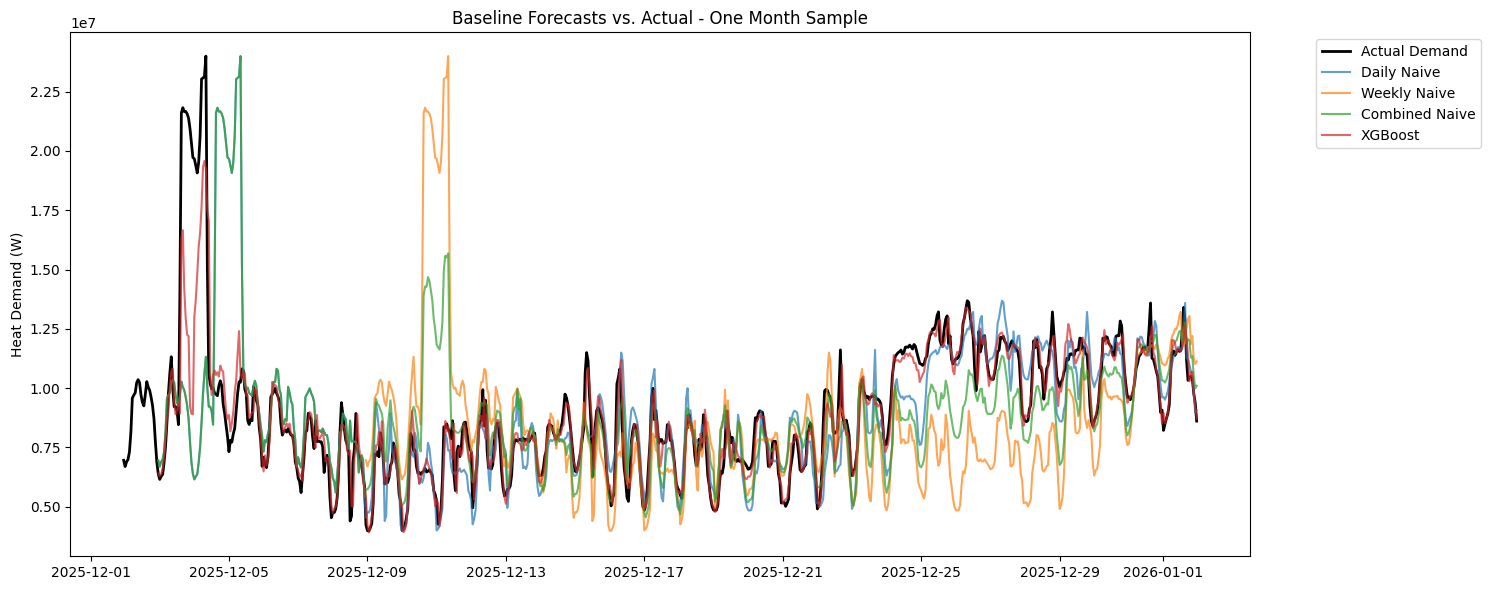

In [41]:
# Visualizing one month of data side-by-side
week_start = '2025-12-01'
week_end = '2026-01-01'

plt.figure(figsize=(15, 6))
plt.plot(y_test[week_start:week_end].index, y_test[week_start:week_end], label='Actual Demand', color='black', linewidth=2)

for name, pred in predictions.items():
    plt.plot(pred[week_start:week_end].index, pred[week_start:week_end], label=name, alpha=0.7)

plt.title('Baseline Forecasts vs. Actual - One Month Sample')
plt.ylabel('Heat Demand (W)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

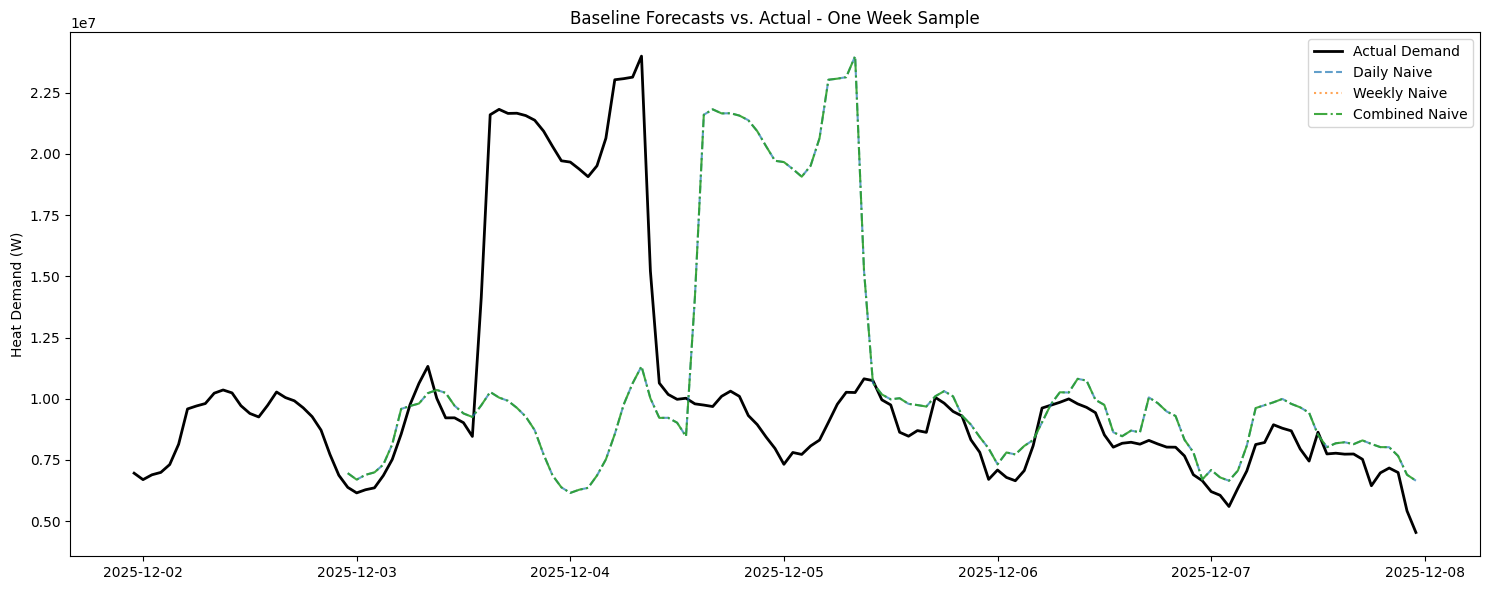

In [ ]:
# Visualizing one week of data side-by-side
week_start = '2025-12-01'
week_end = '2025-12-07'

plt.figure(figsize=(15, 6))
plt.plot(y_test[week_start:week_end].index, y_test[week_start:week_end], label='Actual Demand', color='black', linewidth=2)

for name, pred in predictions.items():
    plt.plot(pred[week_start:week_end].index, pred[week_start:week_end], label=name, alpha=0.7)

plt.title('Baseline Forecasts vs. Actual - One Week Sample')
plt.ylabel('Heat Demand (W)')
plt.legend()
plt.tight_layout()
plt.show()

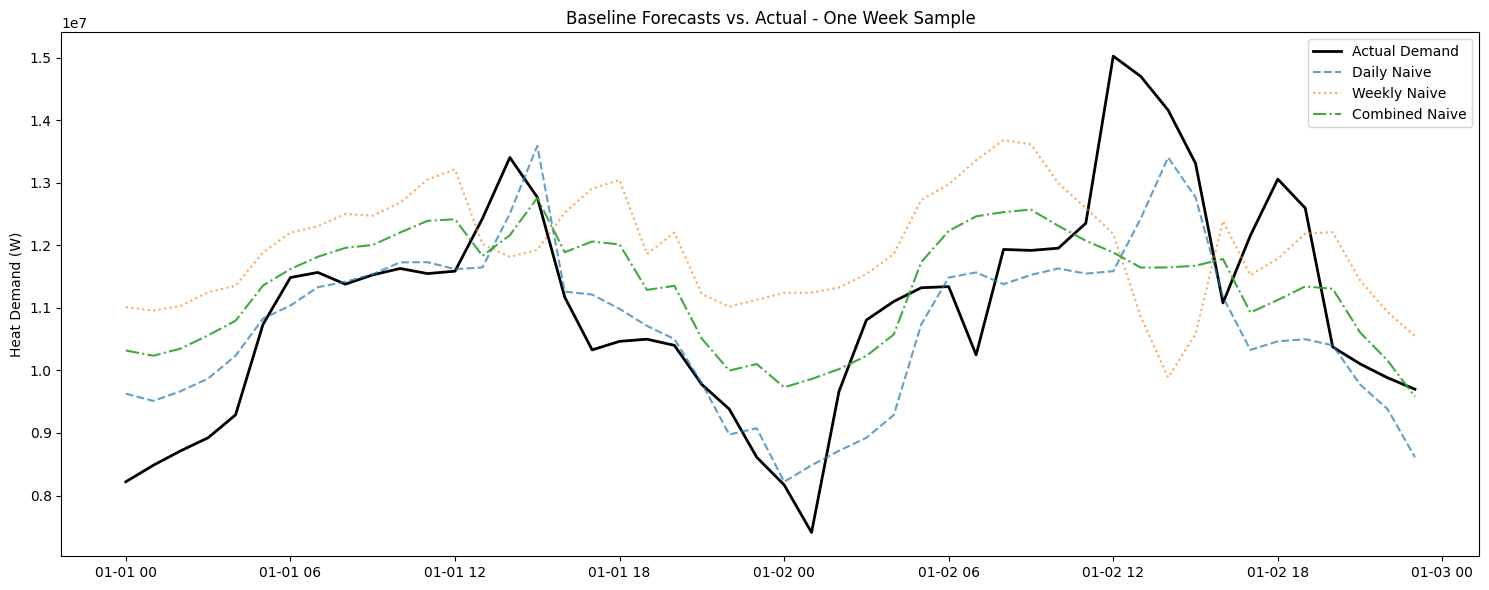

In [ ]:
# Visualizing one day of data side-by-side
week_start = '2026-01-01'
week_end = '2026-01-02'

plt.figure(figsize=(15, 6))
plt.plot(y_test[week_start:week_end].index, y_test[week_start:week_end], label='Actual Demand', color='black', linewidth=2)

for name, pred in predictions.items():
    plt.plot(pred[week_start:week_end].index, pred[week_start:week_end], label=name, alpha=0.7)

plt.title('Baseline Forecasts vs. Actual - One Day Sample')
plt.ylabel('Heat Demand (W)')
plt.legend()
plt.tight_layout()
plt.show()

## Detailed Error Analysis

Let's compare the performance using our updated metrics:
- **MAE (Mean Absolute Error):** The average absolute difference between the forecast and actual demand. It tells us the expected error in Watts.
- **RMSE (Root Mean Squared Error):** Also in Watts, but squares the errors before averaging, effectively penalizing larger errors more heavily. Helpful for checking if the model misses big spikes.
- **MAPE (Mean Absolute Percentage Error):** The average relative percentage error. Useful for understanding the scale of the errors independent of the actual unit volume.
- **R² (Coefficient of Determination):** Measures the proportion of variance explained by the model. 1.0 represents a perfect forecast, 0.0 represents a model no better than just predicting the historical mean, and negative values indicate performance worse than the mean.

,mae,rmse,mape_pct,r2
Daily Naive,1273554.38,2139565.96,13.86,0.32
Weekly Naive,2267606.03,3016617.10,27.92,-0.62
Combined Naive,1575840.81,2428997.80,18.32,0.12


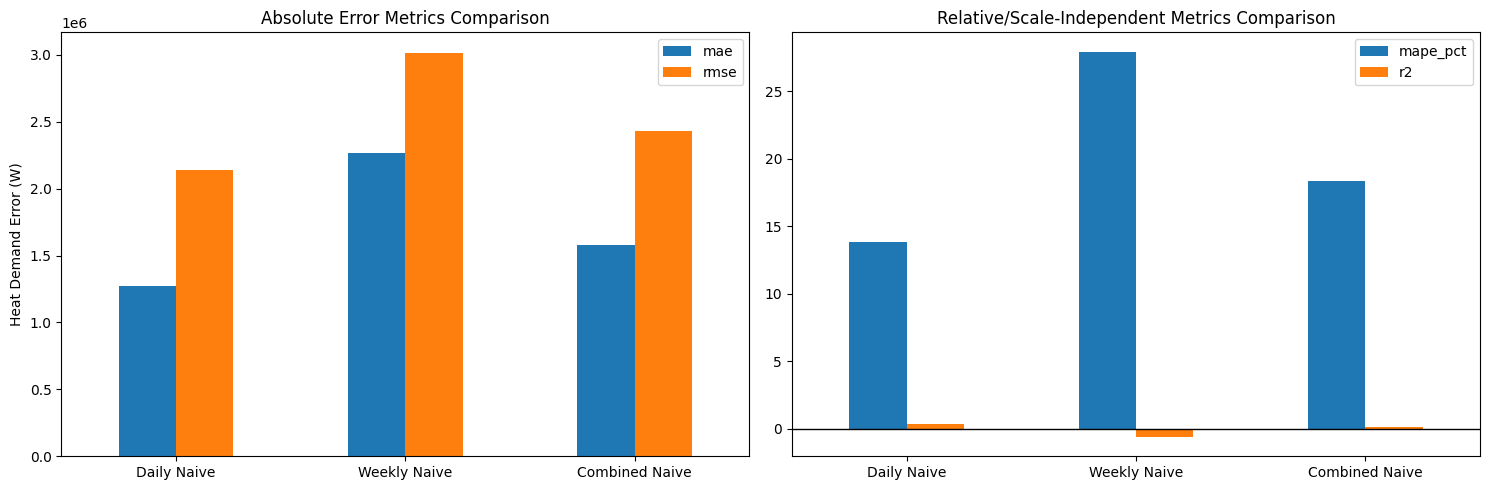

In [ ]:
import numpy as np

# Calculate comprehensive metrics dynamically
metrics_dict = {
    name: evaluate_baselines(y_test, pred)
    for name, pred in predictions.items()
}
metrics_df = pd.DataFrame(metrics_dict).T

# Formatting the output slightly better
display(metrics_df.round(2))

# Plot Metrics Comparison side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MAE & RMSE
metrics_df[['mae', 'rmse']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Absolute Error Metrics Comparison')
axes[0].set_ylabel('Heat Demand Error (W)')
axes[0].tick_params(axis='x', rotation=45)

# MAPE & R2
metrics_df[['mape_pct', 'r2']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Relative/Scale-Independent Metrics Comparison')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

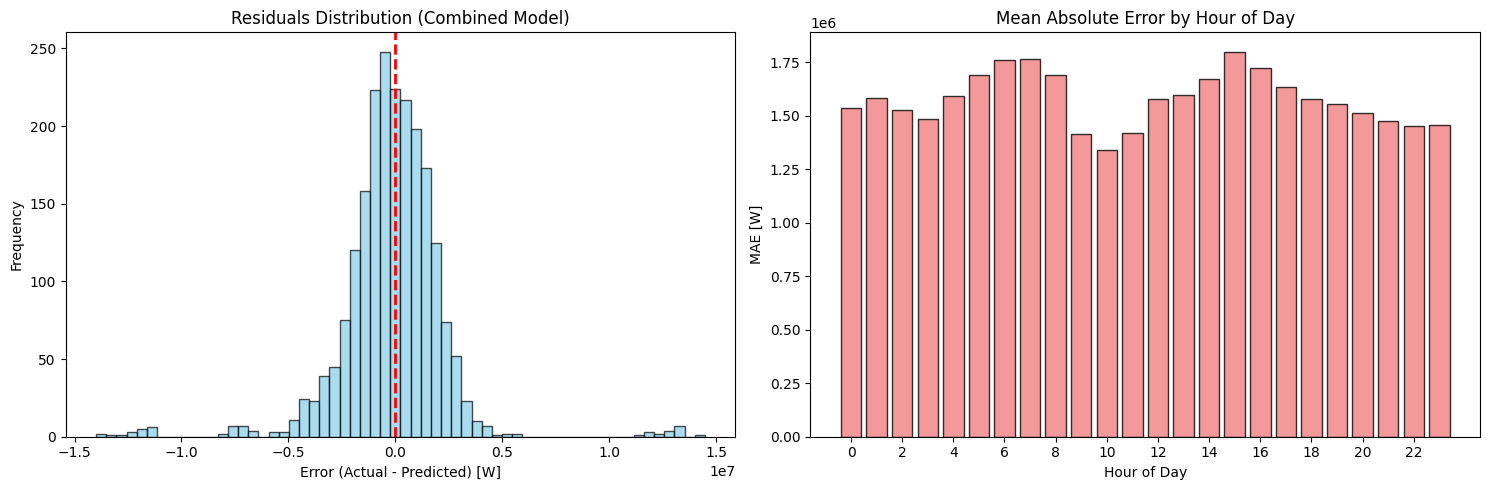

In [ ]:
# Residuals Analysis for a specific model 
# (You can change 'best_model_name' to inspect any model in the dictionary)
best_model_name = 'Combined Naive' 

assert best_model_name in predictions, f"Model {best_model_name} not found in predictions dictionary"
residuals = y_test - predictions[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histogram to evaluate residual normal distribution
axes[0].hist(residuals.dropna(), bins=60, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[0].set_title(f'Residuals Distribution ({best_model_name})')
axes[0].set_xlabel('Error (Actual - Predicted) [W]')
axes[0].set_ylabel('Frequency')

# 2. Mean Absolute Error by Hour of Day
err_df = pd.DataFrame({'residual': residuals, 'hour': residuals.index.hour})
err_by_hour = err_df.groupby('hour')['residual'].apply(lambda x: np.mean(np.abs(x)))

axes[1].bar(err_by_hour.index, err_by_hour.values, color='lightcoral', alpha=0.8, edgecolor='black')
axes[1].set_title(f'Mean Abs Error by Hour ({best_model_name})')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('MAE [W]')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()